Definieer working directory (./), deze is anders dan het directory waar de code staat, voor gemak met uploaden naar GitHub.

In [2]:
%cd C:\\Users\\t.vandenberg\\Documents\\DNA-NL\\use cases testen in notebooks\\DataConnector
%pwd # check of working directory klopt


C:\Users\t.vandenberg\Documents\DNA-NL\use cases testen in notebooks\DataConnector


'C:\\Users\\t.vandenberg\\Documents\\DNA-NL\\use cases testen in notebooks\\DataConnector'

# installeer packages

In [36]:
# %pip install duckdb
# %pip install matplotlib
# %pip install mpl_toolkits
# %pip install shapely

Note: you may need to restart the kernel to use updated packages.


# laad packages

In [1]:
import duckdb
import geopandas as gpd
import pandas as pd
import os
import matplotlib.pyplot as plt
from shapely import wkt


# laad de Spatial Extension
https://duckdb.org/docs/current/core_extensions/spatial/overview

In [9]:
duckdb.sql("""
           INSTALL spatial;
           LOAD spatial;
           """)

# laad databases (schema's) in de bronzen laag

In [10]:
duckdb.sql("""
           CREATE SCHEMA IF NOT EXISTS brons_beschermde_stads_en_dorpsgezichten;
           CREATE SCHEMA IF NOT EXISTS brons_bestuurlijke_gebieden_2026;
           CREATE SCHEMA IF NOT EXISTS brons_publiekrechtelijke_beperkingen;
           CREATE SCHEMA IF NOT EXISTS brons_rijksbeschermde_groenaanleggen;
           CREATE SCHEMA IF NOT EXISTS brons_rijksmonumentale_boerderijen;
           CREATE SCHEMA IF NOT EXISTS brons_beschermde_stads_en_dorpsgezichten;
           CREATE SCHEMA IF NOT EXISTS brons_rijksmonumentale_sluizen_en_stuwen;
           CREATE SCHEMA IF NOT EXISTS brons_rijksmonumentenpunten;
           CREATE SCHEMA IF NOT EXISTS brons_rijksmonumentencontouren;
           CREATE SCHEMA IF NOT EXISTS brons_rijksmonumentenregister;
           CREATE SCHEMA IF NOT EXISTS brons_basisregistratie_adressen_en_gebouwen;
           """)

# laad parquet files als een tabellen in de bronzen laag

In [11]:
# beschermde_stads_en_dorpsgezichten in brons
duckdb.sql("""
           CREATE TABLE IF NOT EXISTS brons_beschermde_stads_en_dorpsgezichten.townscapes AS
           FROM read_parquet('./brons/beschermde_stads_en_dorpsgezichten/townscapes.parquet');
           """)
# bestuurlijke_gebieden_2026 in brons
duckdb.sql("""
           CREATE TABLE IF NOT EXISTS brons_bestuurlijke_gebieden_2026.gemeentegebied AS
           FROM read_parquet('./brons/bestuurlijke_gebieden_2026/gemeentegebied.parquet');
           CREATE TABLE IF NOT EXISTS brons_bestuurlijke_gebieden_2026.landgebied AS
           FROM read_parquet('./brons/bestuurlijke_gebieden_2026/landgebied.parquet');
           CREATE TABLE IF NOT EXISTS brons_bestuurlijke_gebieden_2026.provinciegebied AS
           FROM read_parquet('./brons/bestuurlijke_gebieden_2026/provinciegebied.parquet');
           """)
# publiekrechtelijke_beperkingen in brons
duckdb.sql("""
           CREATE TABLE IF NOT EXISTS brons_publiekrechtelijke_beperkingen.pb_pb_multilinestring AS
           FROM read_parquet('./brons/publiekrechtelijke_beperkingen/pb_multipolygon.parquet');
           CREATE TABLE IF NOT EXISTS brons_publiekrechtelijke_beperkingen.pb_pb_multipolygon AS
           FROM read_parquet('./brons/publiekrechtelijke_beperkingen/pb_multipolygon.parquet');
           """)
# rijksbeschermde_groenaanleggen in brons
duckdb.sql("""
           CREATE TABLE IF NOT EXISTS brons_rijksbeschermde_groenaanleggen.rijksmonumentaal_groen AS
           FROM read_parquet('./brons/rijksbeschermde_groenaanleggen/rijksmonumentaal_groen.parquet');
           """)
# rijksmonumentale_boerderijen in brons
duckdb.sql("""
           CREATE TABLE IF NOT EXISTS brons_rijksmonumentale_boerderijen.boerderijen AS
           FROM read_parquet('./brons/rijksmonumentale_boerderijen/boerderijen.parquet');
           """)
# rijksmonumentale_sluizen_en_stuwen in brons
duckdb.sql("""
           CREATE TABLE IF NOT EXISTS brons_rijksmonumentale_sluizen_en_stuwen.sluizen_stuwen AS
           FROM read_parquet('./brons/rijksmonumentale_sluizen_en_stuwen/sluizen_stuwen.parquet');
           """)
# rijksmonumentenpunten in brons
duckdb.sql("""
            CREATE TABLE IF NOT EXISTS brons_rijksmonumentenpunten.rijksmonumentenpunten AS FROM read_parquet('./brons/rijksmonumentenpunten/rijksmonumentpunten.parquet');
            """)

# rijksmonumentencontouren in brons
duckdb.sql("""
            CREATE TABLE IF NOT EXISTS brons_rijksmonumentencontouren.rijksmonumentencontouren AS FROM read_parquet('./brons/rijksmonumentencontouren/rijksmonumentcontouren.parquet');
            """)
# rijksmonumentenregister in brons
duckdb.sql("""
           CREATE TABLE IF NOT EXISTS brons_rijksmonumentenregister.tblTEXT_OBJECT AS
           FROM read_parquet('./brons/rijksmonumentenregister/tblTEXT_OBJECT.parquet');
           """) # TODO aanvullen met rest relevanten tables
# BAG in brons
duckdb.sql("""
            CREATE TABLE IF NOT EXISTS brons_basisregistratie_adressen_en_gebouwen.pand AS FROM read_parquet(
            './brons/basisregistratie_adressen_en_gebouwen/pand.parquet');
            CREATE TABLE IF NOT EXISTS brons_basisregistratie_adressen_en_gebouwen.verblijfsobject AS FROM read_parquet(
            './brons/basisregistratie_adressen_en_gebouwen/verblijfsobject.parquet');
            CREATE TABLE IF NOT EXISTS brons_basisregistratie_adressen_en_gebouwen.woonplaats AS FROM read_parquet(
            './brons/basisregistratie_adressen_en_gebouwen/woonplaats.parquet');
            """)



# Beschrijf de tabellen in de bronzen laag


## stads en dorpsgezichten

In [5]:
# beschermde_stads_en_dorpsgezichten in brons
duckdb.sql("""
           DESCRIBE  brons_beschermde_stads_en_dorpsgezichten.townscapes;
           """)


┌─────────────┬────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │      column_type       │  null   │   key   │ default │  extra  │
│   varchar   │        varchar         │ varchar │ varchar │ varchar │ varchar │
├─────────────┼────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ bron_id     │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ naam        │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ in_procedu  │ TIMESTAMP              │ YES     │ NULL    │ NULL    │ NULL    │
│ aangewezen  │ TIMESTAMP              │ YES     │ NULL    │ NULL    │ NULL    │
│ jurstatus   │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ datum_begr  │ TIMESTAMP              │ YES     │ NULL    │ NULL    │ NULL    │
│ ondergrond  │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ opperv_ha   │ DOUBLE                 │ YES     │ NULL    │ NULL    │ NULL    │
│ opperv_km2  │ DOUBLE      

### gemeentegebied

In [8]:
duckdb.sql("""
           DESCRIBE  brons_bestuurlijke_gebieden_2026.gemeentegebied;
           """)

┌────────────────────────┬────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name       │      column_type       │  null   │   key   │ default │  extra  │
│        varchar         │        varchar         │ varchar │ varchar │ varchar │ varchar │
├────────────────────────┼────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ identificatie          │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ naam                   │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ code                   │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ ligt_in_provincie_code │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ ligt_in_provincie_naam │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ geometry               │ GEOMETRY('EPSG:28992') │ YES     │ NULL    │ NULL    │ NULL    │
└────────────────────────┴────────────────────────┴─────────┴─────────┴─────────

## landgebied

In [7]:
duckdb.sql("""
           DESCRIBE  brons_bestuurlijke_gebieden_2026.landgebied;
           """)

┌───────────────┬────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│  column_name  │      column_type       │  null   │   key   │ default │  extra  │
│    varchar    │        varchar         │ varchar │ varchar │ varchar │ varchar │
├───────────────┼────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ identificatie │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ naam          │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ code          │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ geometry      │ GEOMETRY('EPSG:28992') │ YES     │ NULL    │ NULL    │ NULL    │
└───────────────┴────────────────────────┴─────────┴─────────┴─────────┴─────────┘

## Provinciegebied

In [8]:
duckdb.sql("""
           DESCRIBE  brons_bestuurlijke_gebieden_2026.gemeentegebied;
           """)

┌────────────────────────┬────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name       │      column_type       │  null   │   key   │ default │  extra  │
│        varchar         │        varchar         │ varchar │ varchar │ varchar │ varchar │
├────────────────────────┼────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ identificatie          │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ naam                   │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ code                   │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ ligt_in_provincie_code │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ ligt_in_provincie_naam │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ geometry               │ GEOMETRY('EPSG:28992') │ YES     │ NULL    │ NULL    │ NULL    │
└────────────────────────┴────────────────────────┴─────────┴─────────┴─────────

## Publieksrechtelijke bescherming lijn

In [9]:
duckdb.sql("""
           DESCRIBE  brons_publiekrechtelijke_beperkingen.pb_pb_multilinestring;
           """)

┌──────────────────────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│             column_name              │       column_type        │  null   │   key   │ default │  extra  │
│               varchar                │         varchar          │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ identificatie                        │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ domein                               │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ code_groep                           │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ naam_groep                           │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ grondslag_code                       │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ grondslag_omschrijving    

## Publieksrechtelijke bescherming vlak

In [10]:
duckdb.sql("""
           DESCRIBE  brons_publiekrechtelijke_beperkingen.pb_pb_multipolygon;
           """)

┌──────────────────────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│             column_name              │       column_type        │  null   │   key   │ default │  extra  │
│               varchar                │         varchar          │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ identificatie                        │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ domein                               │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ code_groep                           │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ naam_groep                           │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ grondslag_code                       │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ grondslag_omschrijving    

## Rijksmonumentaal groen

In [6]:
duckdb.sql("""
           DESCRIBE  brons_rijksbeschermde_groenaanleggen.rijksmonumentaal_groen;
           """)

┌──────────────┬────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name  │      column_type       │  null   │   key   │ default │  extra  │
│   varchar    │        varchar         │ varchar │ varchar │ varchar │ varchar │
├──────────────┼────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ monumentnr   │ INTEGER                │ YES     │ NULL    │ NULL    │ NULL    │
│ complex      │ DOUBLE                 │ YES     │ NULL    │ NULL    │ NULL    │
│ categorie    │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ cat_legenda  │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ naam         │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ type_aanleg  │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ foto_thumb   │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ foto_groot   │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ fotograaf    │

## rijskmonumentable boerderijen

In [7]:
duckdb.sql("""
           DESCRIBE  brons_rijksmonumentale_boerderijen.boerderijen;
           """)

┌──────────────────────┬────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name      │      column_type       │  null   │   key   │ default │  extra  │
│       varchar        │        varchar         │ varchar │ varchar │ varchar │ varchar │
├──────────────────────┼────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ monumentnr           │ INTEGER                │ YES     │ NULL    │ NULL    │ NULL    │
│ complexnr            │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ hoofdcategorie       │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ subcategorie         │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ url                  │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ mon_omschrijving_500 │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ in_welke_set         │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ geometry

## Stuwen en Sluizen

In [12]:
duckdb.sql("""
           DESCRIBE  brons_rijksmonumentale_sluizen_en_stuwen.sluizen_stuwen;
           """)

┌─────────────┬────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │      column_type       │  null   │   key   │ default │  extra  │
│   varchar   │        varchar         │ varchar │ varchar │ varchar │ varchar │
├─────────────┼────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ monumentnr  │ INTEGER                │ YES     │ NULL    │ NULL    │ NULL    │
│ geometry    │ GEOMETRY('EPSG:28992') │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴────────────────────────┴─────────┴─────────┴─────────┴─────────┘

## Rijksmonumentenpunten

In [6]:
duckdb.sql("""
           DESCRIBE  brons_rijksmonumentenpunten.rijksmonumentenpunten;
           """)

┌──────────────────────┬────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name      │      column_type       │  null   │   key   │ default │  extra  │
│       varchar        │        varchar         │ varchar │ varchar │ varchar │ varchar │
├──────────────────────┼────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ gml_id               │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ id                   │ BIGINT                 │ YES     │ NULL    │ NULL    │ NULL    │
│ rijksmonument_nummer │ INTEGER                │ YES     │ NULL    │ NULL    │ NULL    │
│ complex_nummer       │ DOUBLE                 │ YES     │ NULL    │ NULL    │ NULL    │
│ juridische_status    │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ aard_monument        │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ herkomst             │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ kwalitei

## Rijksmonumentencontouren

In [7]:
duckdb.sql("""
           DESCRIBE  brons_rijksmonumentencontouren.rijksmonumentencontouren;
           """)

┌──────────────────────┬────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name      │      column_type       │  null   │   key   │ default │  extra  │
│       varchar        │        varchar         │ varchar │ varchar │ varchar │ varchar │
├──────────────────────┼────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ gml_id               │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ id                   │ BIGINT                 │ YES     │ NULL    │ NULL    │ NULL    │
│ rijksmonument_nummer │ INTEGER                │ YES     │ NULL    │ NULL    │ NULL    │
│ complex_nummer       │ DOUBLE                 │ YES     │ NULL    │ NULL    │ NULL    │
│ juridische_status    │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ aard_monument        │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ herkomst             │ VARCHAR                │ YES     │ NULL    │ NULL    │ NULL    │
│ kwalitei

## tblTEXT_OBJECT (rms)

In [13]:
duckdb.sql("""
           DESCRIBE  brons_rijksmonumentenregister.tblTEXT_OBJECT;
           """)

┌───────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name    │ column_type │  null   │   key   │ default │  extra  │
│      varchar      │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ TXO_TEXT_KEY      │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ OBJ_NUMMER        │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ TXO_CREATIE_DATUM │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ TXO_IND_ACT_HIST  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ KIO_CREATIE_DATUM │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ TXO_ACT_DATUM     │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ TXO_SOORT         │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ TXO_TEKST         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ TXO_SOORT_ZKP     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
└───────────

## nog meer?

In [ ]:
duckdb.sql("""
           DESCRIBE  brons_voorbeeld.voorbeeld;
           """)

# Testjes

Selecteer de geometrie en laat zien.

In [8]:
df= duckdb.sql("""SELECT ST_asText(geometry) FROM brons_beschermde_stads_en_dorpsgezichten.townscapes;
           """).fetchdf()
df

,st_astext(geometry)
0,"POLYGON ((244586.3 534143.7, 244605.9 534162, ..."
1,"POLYGON ((242801.1 562418.2, 242788.4 562409.2..."
2,"POLYGON ((247019.7 532667, 247012 532664.2, 24..."
3,"POLYGON ((220824.9 538924.4, 220845.7 538940.1..."
4,"POLYGON ((223600.5 524937.5, 223508.1 524963.5..."
...,...
468,"POLYGON ((80908.25 457085.747, 80913.899 45708..."
469,"POLYGON ((79584.87225 456944.96275, 80074.7112..."
470,"POLYGON ((81667.63425 455866.02575, 81549.053 ..."
471,"POLYGON ((79554.79425 457915.0045, 79556.252 4..."


join twee databases met elkaar op rijksmonumentnummer

In [9]:
df = duckdb.sql(
    """
    SELECT x.*, y.*
    FROM
    brons_beschermde_stads_en_dorpsgezichten.townscapes x
    JOIN
    brons_rijksmonumentenregister.tblTEXT_OBJECT y
    ON
    x.bron_id = y.OBJ_NUMMER
    """
).fetchdf()
df

,bron_id,naam,in_procedu,aangewezen,jurstatus,datum_begr,ondergrond,opperv_ha,opperv_km2,centroid_x,...,geometry,TXO_TEXT_KEY,OBJ_NUMMER,TXO_CREATIE_DATUM,TXO_IND_ACT_HIST,KIO_CREATIE_DATUM,TXO_ACT_DATUM,TXO_SOORT,TXO_TEKST,TXO_SOORT_ZKP
0,1345,Oosterend (Fryslân),1988-02-18,1991-03-28,rijksbeschermd stads- of dorpsgezicht,NaT,TOP10vector,7.7,0.1,170545,...,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 60, 0, 0, 0, 102, ...",190552,1345,1992-03-28,A,<NA>,<NA>,<NA>,Pand met uit- en ingezwenkte halsgevel (begin ...,rijksmonumentomschrijving
1,1347,Oost-Vlieland,1969-11-11,1971-11-05,rijksbeschermd stads- of dorpsgezicht,2000-11-01,TOP10vector,9.8,0.1,133681,...,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 67, 0, 0, 0, 154, ...",190610,1347,1992-03-28,A,<NA>,<NA>,<NA>,17e eeuws huis met 18e eeuwse gevel onder 19e ...,rijksmonumentomschrijving
2,1349,Oldeberkoop,1987-11-05,1991-09-27,rijksbeschermd stads- of dorpsgezicht,2000-11-01,TOP10vector,7.9,0.1,204911,...,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 31, 0, 0, 0, 0, 0,...",190645,1349,1992-03-28,A,<NA>,<NA>,<NA>,17e eeuws huis met 18e eeuwse gevel onder 19e ...,rijksmonumentomschrijving
3,1351,Nes,1966-10-03,1969-06-10,rijksbeschermd stads- of dorpsgezicht,NaT,TOP10vector,8.4,0.1,180565,...,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 53, 0, 0, 0, 51, 5...",190652,1351,1992-03-28,A,<NA>,<NA>,<NA>,17e eeuws huis met 18e eeuwse gevel onder 19e ...,rijksmonumentomschrijving
4,1353,Metslawier,1986-11-13,1990-10-10,rijksbeschermd stads- of dorpsgezicht,NaT,TOP10vector,8.0,0.1,200372,...,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 38, 0, 0, 0, 0, 0,...",190701,1353,1992-03-28,A,<NA>,<NA>,<NA>,Pand met ingezwenkte halsgevel van vloeiend si...,rijksmonumentomschrijving
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,1368,Hogebeintum,1987-11-05,1991-09-27,rijksbeschermd stads- of dorpsgezicht,2000-11-01,TOP10vector,58.1,0.6,185988,...,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 103, 0, 0, 0, 205,...",229241,1368,1992-03-28,A,<NA>,<NA>,<NA>,Pand met halsgevel (1737) met gedeelde vleugel...,rijksmonumentomschrijving
455,1565,Marsum,1987-11-04,1991-09-27,rijksbeschermd stads- of dorpsgezicht,NaT,onbekend,20.7,0.2,254094,...,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 95, 0, 0, 0, 51, 5...",229256,1565,1987-08-24,A,<NA>,<NA>,<NA>,"Huis, vanwege de zandstenen onderdelen van de ...",rijksmonumentomschrijving
456,1370,Heeg,1988-11-23,1991-09-27,rijksbeschermd stads- of dorpsgezicht,NaT,TOP10vector,6.0,0.1,169626,...,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 81, 0, 0, 0, 154, ...",229428,1370,1992-03-28,A,<NA>,<NA>,<NA>,Pand met tot ingezwenkte halsgevel gewijzigde ...,rijksmonumentomschrijving
457,1418,Zoelen,1976-03-16,1980-02-18,rijksbeschermd stads- of dorpsgezicht,NaT,onbekend,99.8,1.0,155873,...,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 90, 0, 0, 0, 51, 5...",229440,1418,1992-03-28,A,<NA>,<NA>,<NA>,Pand met ingezwenkte halsgevel (XVIIIc).\r\n,rijksmonumentomschrijving


Maak een kaartje met de stads- en dorpsgezichten van Amersfoort, met daarbinnen punten van gebouwen die ook rijksmonumenten zijn (zelfde testje als Stan)

In [10]:
stadsgezichten_amersfoort = duckdb.sql("""
SELECT ST_asText(geometry) as geometry,naam
FROM brons_beschermde_stads_en_dorpsgezichten.townscapes
WHERE ST_Within(
    geometry,
    (
        SELECT geometry
        FROM brons_bestuurlijke_gebieden_2026.gemeentegebied
        WHERE naam = 'Amersfoort'
    )
);""").fetchdf()
stadsgezichten_amersfoort
stadsgezichten_amersfoort['geometry'] = stadsgezichten_amersfoort['geometry'].apply(wkt.loads)
stadsgezichten_amersfoort = gpd.GeoDataFrame(stadsgezichten_amersfoort, geometry='geometry')


In [23]:
rijksmon_in_stad_amersfoort = duckdb.sql("""
SELECT ST_asText(geometry) as geometry,rijksmonument_nummer
FROM brons_rijksmonumentenpunten.rijksmonumentenpunten
WHERE ST_Within(geometry,
    (SELECT ST_collect(list(geometry))
        FROM brons_beschermde_stads_en_dorpsgezichten.townscapes
        WHERE ST_Within(
            geometry,
                (
                SELECT geometry
                FROM brons_bestuurlijke_gebieden_2026.gemeentegebied
                WHERE naam = 'Amersfoort'
                )
            )
        )
);""").fetchdf()
rijksmon_in_stad_amersfoort['geometry'] = rijksmon_in_stad_amersfoort['geometry'].apply(wkt.loads)
rijksmon_in_stad_amersfoort = gpd.GeoDataFrame(rijksmon_in_stad_amersfoort, geometry='geometry')
rijksmon_in_stad_amersfoort

,geometry,rijksmonument_nummer
0,POINT (154977 463279),517727
1,POINT (155259 463290),8010
2,POINT (155312 462872),8095
3,POINT (154966.372 463231.498),7955
4,POINT (155081 462978),7977
...,...,...
366,POINT (155447 463411),324415
367,POINT (155418 463432),324413
368,POINT (153020.368 461624.201),517654
369,POINT (152959.959 461636.184),517655


0      Annotation(154977, 463279, '517727')
1        Annotation(155259, 463290, '8010')
2        Annotation(155312, 462872, '8095')
3        Annotation(154966, 463231, '7955')
4        Annotation(155081, 462978, '7977')
                       ...                 
366    Annotation(155447, 463411, '324415')
367    Annotation(155418, 463432, '324413')
368    Annotation(153020, 461624, '517654')
369    Annotation(152960, 461636, '517655')
370    Annotation(152959, 461660, '517656')
Length: 371, dtype: object

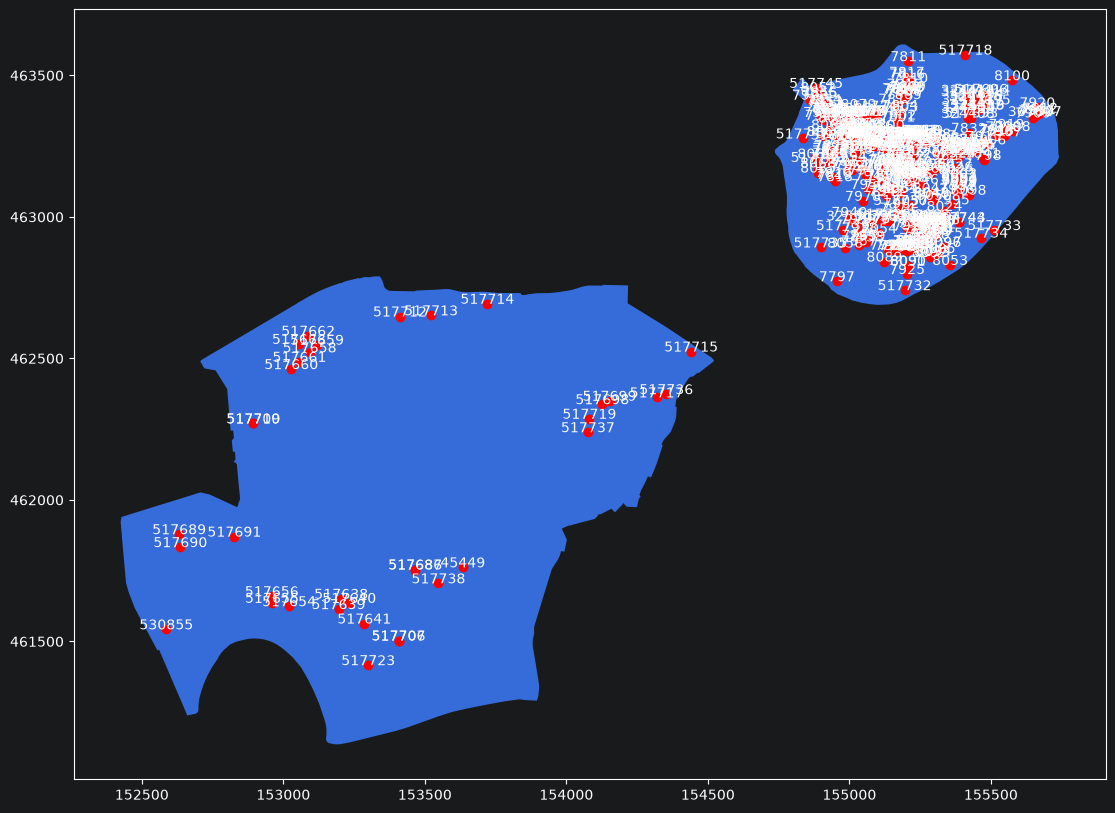

In [35]:
fig, ax = plt.subplots(figsize=(20, 10))
stadsgezichten_amersfoort.explore(ax=ax)
rijksmon_in_stad_amersfoort.explore(ax = ax, color='red')
rijksmon_in_stad_amersfoort.apply(lambda x: ax.annotate(text=x['rijksmonument_nummer'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1)

# Sla dingen op

Zet save directory (binnen working directory, of met volledige path)

In [78]:
save_directory = os.path.normpath(r".\\saved_parquet_files")
if not os.path.exists(save_directory):
    # maak directory als deze nog niet bestaat
     os.mkdir(save_directory)


sla output van een query op

In [27]:
file_name = 'query_output.parquet'
duckdb.sql(f"""
            COPY
                (SELECT x.*, y.*
                FROM
                brons_beschermde_stads_en_dorpsgezichten.townscapes x
                JOIN
                brons_rijksmonumentenregister.tblTEXT_OBJECT y
                ON
                x.bron_id = y.OBJ_NUMMER)
                TO '{os.path.join(save_directory, file_name)}'
                (FORMAT parquet);""")

# alternatief
duckdb.sql(f"""SELECT x.*, y.*
                FROM
                brons_beschermde_stads_en_dorpsgezichten.townscapes x
                JOIN
                brons_rijksmonumentenregister.tblTEXT_OBJECT y
                ON
                x.bron_id = y.OBJ_NUMMER""").write_parquet(os.path.join(save_directory, file_name))


sla de hele database op (als parquet, maar includief load.sql en schema.sql)
let op, kan even duren (als je bijvoorbeeld de BAG ook open hebt staan...)

In [28]:
def save_complete_duckdb_memory(save_directory):
    """saves entire in-memory duckdb database to the given save_directory"""
    duckdb.sql(f"""EXPORT DATABASE '{save_directory}' (FORMAT parquet)""" )

drop alles (de "memory" database kan niet worden gesloten)

In [76]:
def empty_duckdb_memory():
    """Empty the in-memory duckdb database"""
    schemas = duckdb.sql("""
                SELECT schema_name
                FROM information_schema.schemata
                WHERE schema_name NOT IN ('information_schema', 'pg_catalog', 'temp', 'main')""").fetchdf()
    for schema in schemas['schema_name']:
        tables = duckdb.sql(f"""
                        SELECT table_name
                        FROM information_schema.tables
                        WHERE table_schema = '{schema}'
        """).fetchdf()
        for table in tables['table_name']:
            duckdb.sql(f"DROP TABLE IF EXISTS {schema}.{table}")
        duckdb.sql(f"DROP SCHEMA IF EXISTS {schema}")


┌───────────────┬─────────────┬─────────┐
│ database_name │ schema_name │ current │
│    varchar    │   varchar   │ boolean │
├───────────────┼─────────────┼─────────┤
│ memory        │ main        │ true    │
└───────────────┴─────────────┴─────────┘

In [36]:
duckdb.sql("SHOW SCHEMAS;") # check of ze weg zijn


┌───────────────┬─────────────────────────────────────────────┬─────────┐
│ database_name │                 schema_name                 │ current │
│    varchar    │                   varchar                   │ boolean │
├───────────────┼─────────────────────────────────────────────┼─────────┤
│ memory        │ brons_basisregistratie_adressen_en_gebouwen │ false   │
│ memory        │ brons_beschermde_stads_en_dorpsgezichten    │ false   │
│ memory        │ brons_bestuurlijke_gebieden_2026            │ false   │
│ memory        │ brons_publiekrechtelijke_beperkingen        │ false   │
│ memory        │ brons_rijksbeschermde_groenaanleggen        │ false   │
│ memory        │ brons_rijksmonumentale_boerderijen          │ false   │
│ memory        │ brons_rijksmonumentale_sluizen_en_stuwen    │ false   │
│ memory        │ brons_rijksmonumentencontouren              │ false   │
│ memory        │ brons_rijksmonumentenpunten                 │ false   │
│ memory        │ brons_rijksmonumente

laad die hele database weer in (kan eventjes duren, wederom, vooral als je het BAG hebt ingeladen)

In [80]:
def load_duckdbset_to_memory(load_directory):
    """Loads an entire saved set of parquet files from the included "schema.sql" and "load.sql" files."""

    file_name = 'schema.sql'
    with open(os.path.join(load_directory, file_name), 'r') as schema:
        duckdb.sql(schema.read())

    file_name = 'load.sql'
    with open(os.path.join(load_directory, file_name), 'r') as load:
        duckdb.sql(load.read())
    duckdb.sql("SHOW SCHEMAS;")

CatalogException: Catalog Error: Schema with name "brons_basisregistratie_adressen_en_gebouwen" already exists!

# Pas de datakwaliteits richtlijnen toe



In [ ]:
pass